# 🔬 Lab Day 19: Xây dựng Hệ thống GraphRAG với Tech Company Corpus

**Mục tiêu:**
- Trích xuất thực thể (Entity Extraction) và quan hệ (Relation Extraction) từ văn bản thô
- Xây dựng Knowledge Graph bằng NetworkX
- So sánh Flat RAG vs GraphRAG trên 20 câu hỏi benchmark
- Phân tích chi phí (thời gian, token)

**💡 Model offline 100% – không tốn API:**
- `sentence-transformers` (all-MiniLM-L6-v2) cho embedding
- `spaCy` (en_core_web_sm) cho NER
- `FAISS` cho vector search
- `NetworkX` + `Matplotlib` cho đồ thị


In [1]:
%%capture
!pip install networkx matplotlib sentence-transformers faiss-cpu spacy langchain langchain-community
!python -m spacy download en_core_web_sm

In [2]:
import os, zipfile, time, re, json, warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import faiss
import spacy
from sentence_transformers import SentenceTransformer
from collections import defaultdict
from itertools import combinations
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
from google.colab import drive

# 1. Mount Google Drive vao Colab (Neu da mount roi, Colab se tu dong bo qua)
drive.mount('/content/drive')

# 2. Thay doi duong dan toi thu muc tren Drive cua ban
DATASET_DIR = '/content/drive/MyDrive/day19/dataset'

# 3. Kiem tra thu muc va liet ke file
if os.path.exists(DATASET_DIR):
    print(f'✅ Da tim thay thu muc Dataset tai: {DATASET_DIR}')

    # Lay danh sach va sap xep tat ca cac file .txt
    all_files = sorted([f for f in os.listdir(DATASET_DIR) if f.endswith('.txt')])
    print(f'Tong so file .txt hien co: {len(all_files)}')
else:
    print(f'❌ Khong tim thay thu muc tai duong dan: {DATASET_DIR}')
    print('Vui long kiem tra lai ten thu muc hoac dam bao Drive da duoc ket noi dung.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Da tim thay thu muc Dataset tai: /content/drive/MyDrive/day19/dataset
Tong so file .txt hien co: 70


In [6]:
def parse_doc(filepath):
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        raw = f.read()
    info = {}
    for field in ['Query', 'Title', 'Link', 'Snippet']:
        m = re.search(rf'^{field}: (.+)', raw, re.MULTILINE)
        info[field.lower()] = m.group(1).strip() if m else ''
    fc_match = re.search(r'Full Content:\s*(.+)', raw, re.DOTALL)
    info['content'] = fc_match.group(1).strip() if fc_match else raw
    return info

MAX_DOCS = 40
SKIP_LARGE = 5_000_000
docs = []
for fname in all_files[:MAX_DOCS]:
    path = os.path.join(DATASET_DIR, fname)
    if os.path.getsize(path) > SKIP_LARGE:
        continue
    d = parse_doc(path)
    d['filename'] = fname
    docs.append(d)

print(f'Da load {len(docs)} documents')
print(f'Vi du query: "{docs[0]["query"]}"')

Da load 40 documents
Vi du query: "US electric vehicle sector sentiment analysis"


In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=80,
    separators=['\n\n', '\n', '. ', ' ', '']
)

chunks = []
for doc in docs:
    splits = splitter.split_text(doc['content'])
    for i, chunk_text in enumerate(splits):
        if len(chunk_text.strip()) < 50:
            continue
        chunks.append({
            'id': f"{doc['filename']}_{i}",
            'text': chunk_text.strip(),
            'source': doc['title'],
            'query_topic': doc['query'],
        })

print(f'Tong so chunks: {len(chunks)}')
print(f'Avg chunk length: {np.mean([len(c["text"]) for c in chunks]):.0f} chars')
print(f'\nChunk mau:\n{chunks[10]["text"][:300]}')

Tong so chunks: 2525
Avg chunk length: 347 chars

Chunk mau:
We use cookies to improve site functionality and make this website more useful to visitors. Find out more.
This website uses cookies to enable some basic functionality and also to help us understand how visitors use the site, so that we can improve it.
Essential cookies provide basic core functional


In [11]:
nlp = spacy.load('en_core_web_sm')
KEEP_TYPES = {'ORG', 'PERSON', 'GPE', 'PRODUCT', 'NORP', 'FAC', 'MONEY', 'PERCENT'}

TECH_ENTITIES = {
    'Tesla', 'BYD', 'Ford', 'GM', 'General Motors', 'Rivian', 'Lucid',
    'Toyota', 'Volkswagen', 'BMW', 'Mercedes', 'Hyundai', 'Kia',
    'Elon Musk', 'Sam Altman', 'Warren Buffett', 'Berkshire Hathaway',
    'OpenAI', 'Google', 'Apple', 'Amazon', 'Microsoft', 'Uber',
    'CATL', 'Panasonic', 'LG Energy', 'Samsung SDI',
    'China', 'United States', 'US', 'Europe', 'EU', 'Germany', 'Japan',
    'SEC', 'EPA', 'DOE', 'IRA', 'NHTSA',
    'Model 3', 'Model Y', 'Cybertruck', 'Model S', 'Seagull', 'BYD Han'
}

def extract_entities_from_chunk(text):
    doc = nlp(text[:nlp.max_length])
    entities = set()
    for ent in doc.ents:
        if ent.label_ in KEEP_TYPES and len(ent.text.strip()) > 1:
            entities.add((ent.text.strip(), ent.label_))
    for tech_ent in TECH_ENTITIES:
        if tech_ent.lower() in text.lower():
            etype = 'PERSON' if tech_ent in {'Elon Musk', 'Sam Altman', 'Warren Buffett'} else 'ORG'
            entities.add((tech_ent, etype))
    return entities

print('Dang trich xuat thuc the...')
t0 = time.time()
chunk_entities = {}
for c in chunks:
    chunk_entities[c['id']] = extract_entities_from_chunk(c['text'])

all_entity_names = set()
for ents in chunk_entities.values():
    all_entity_names.update(e[0] for e in ents)

t_ner = time.time() - t0
print(f'NER xong trong {t_ner:.1f}s')
print(f'Tong thuc the unique: {len(all_entity_names)}')
print(f'Vi du: {list(all_entity_names)[:15]}')

Dang trich xuat thuc the...
NER xong trong 39.4s
Tong thuc the unique: 3048
Vi du: ['eCitan', '19 per cent', 'Blade LFP', '2%', 'Europe', 'the People’s Bank of China', 'Newsom', 'Wang Wentao', 'Kota Yuzawa', 'Hybrids Growth', 'Models 3', '32', '33.8 percent', 'Mark J. Greeven', 'Chengdu Xiwu Security']


In [12]:
RELATION_PATTERNS = [
    (r'founded by|co-founded by|created by|established by', 'FOUNDED_BY'),
    (r'CEO|chief executive|led by|headed by', 'LED_BY'),
    (r'competes? with|competitor|rival', 'COMPETES_WITH'),
    (r'acquired|bought|purchased|takeover', 'ACQUIRED'),
    (r'partnered? with|partnership|collaboration', 'PARTNERS_WITH'),
    (r'invested? in|investor|backed by|funding', 'INVESTED_IN'),
    (r'operates? in|located in|headquartered in|based in', 'LOCATED_IN'),
    (r'manufactures?|produces?|makes?|sells?', 'MANUFACTURES'),
    (r'surpassed?|overtook?|ahead of|beat', 'SURPASSED'),
]

def infer_relation(text, e1, e2):
    text_lower = text.lower()
    for pattern, rel_type in RELATION_PATTERNS:
        if re.search(pattern, text_lower):
            return rel_type
    return 'RELATED_TO'

print('Dang xay dung triples...')
triples = []
relation_counter = defaultdict(int)
for c in chunks:
    ents = list(chunk_entities[c['id']])
    top_ents = [e[0] for e in ents[:5]]
    for e1, e2 in combinations(top_ents, 2):
        rel = infer_relation(c['text'], e1, e2)
        triples.append((e1, rel, e2, c['id']))
        relation_counter[rel] += 1

print(f'Tong triples: {len(triples)}')
print('Phan phoi loai quan he:')
for rel, cnt in sorted(relation_counter.items(), key=lambda x: -x[1]):
    print(f'  {rel}: {cnt}')
print('\n5 triples mau:')
for t in triples[:5]:
    print(f'  ({t[0]}, {t[1]}, {t[2]})')

Dang xay dung triples...
Tong triples: 15166
Phan phoi loai quan he:
  RELATED_TO: 11284
  MANUFACTURES: 2419
  INVESTED_IN: 476
  COMPETES_WITH: 296
  SURPASSED: 225
  PARTNERS_WITH: 200
  LOCATED_IN: 117
  LED_BY: 90
  ACQUIRED: 46
  FOUNDED_BY: 13

5 triples mau:
  (Peter Slowik, RELATED_TO, Anh Bui)
  (Peter Slowik, RELATED_TO, Nic Lutsey)
  (Peter Slowik, RELATED_TO, Briefing)
  (Anh Bui, RELATED_TO, Nic Lutsey)
  (Anh Bui, RELATED_TO, Briefing)


In [13]:
G = nx.MultiDiGraph()
entity_type_map = {}
for c in chunks:
    for ent_name, ent_type in chunk_entities[c['id']]:
        entity_type_map[ent_name] = ent_type
for ent_name, ent_type in entity_type_map.items():
    G.add_node(ent_name, entity_type=ent_type)
for e1, rel, e2, chunk_id in triples:
    G.add_edge(e1, e2, relation=rel, source=chunk_id)

print(f'Knowledge Graph da xay dung xong!')
print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')
deg = dict(G.degree())
top10 = sorted(deg.items(), key=lambda x: -x[1])[:10]
print('\nTop 10 nodes (by degree):')
for node, d in top10:
    print(f'  {node} ({entity_type_map.get(node,"?")}) -- degree {d}')

Knowledge Graph da xay dung xong!
Nodes: 3048
Edges: 15166

Top 10 nodes (by degree):
  US (ORG) -- degree 6782
  China (ORG) -- degree 2556
  EV (ORG) -- degree 1369
  SEC (ORG) -- degree 1360
  United States (ORG) -- degree 515
  Chinese (NORP) -- degree 496
  EPA (ORG) -- degree 398
  Biden (PERSON) -- degree 310
  EU (ORG) -- degree 270
  Europe (ORG) -- degree 263


In [26]:
pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 95.9 MB/s eta 0:00:00


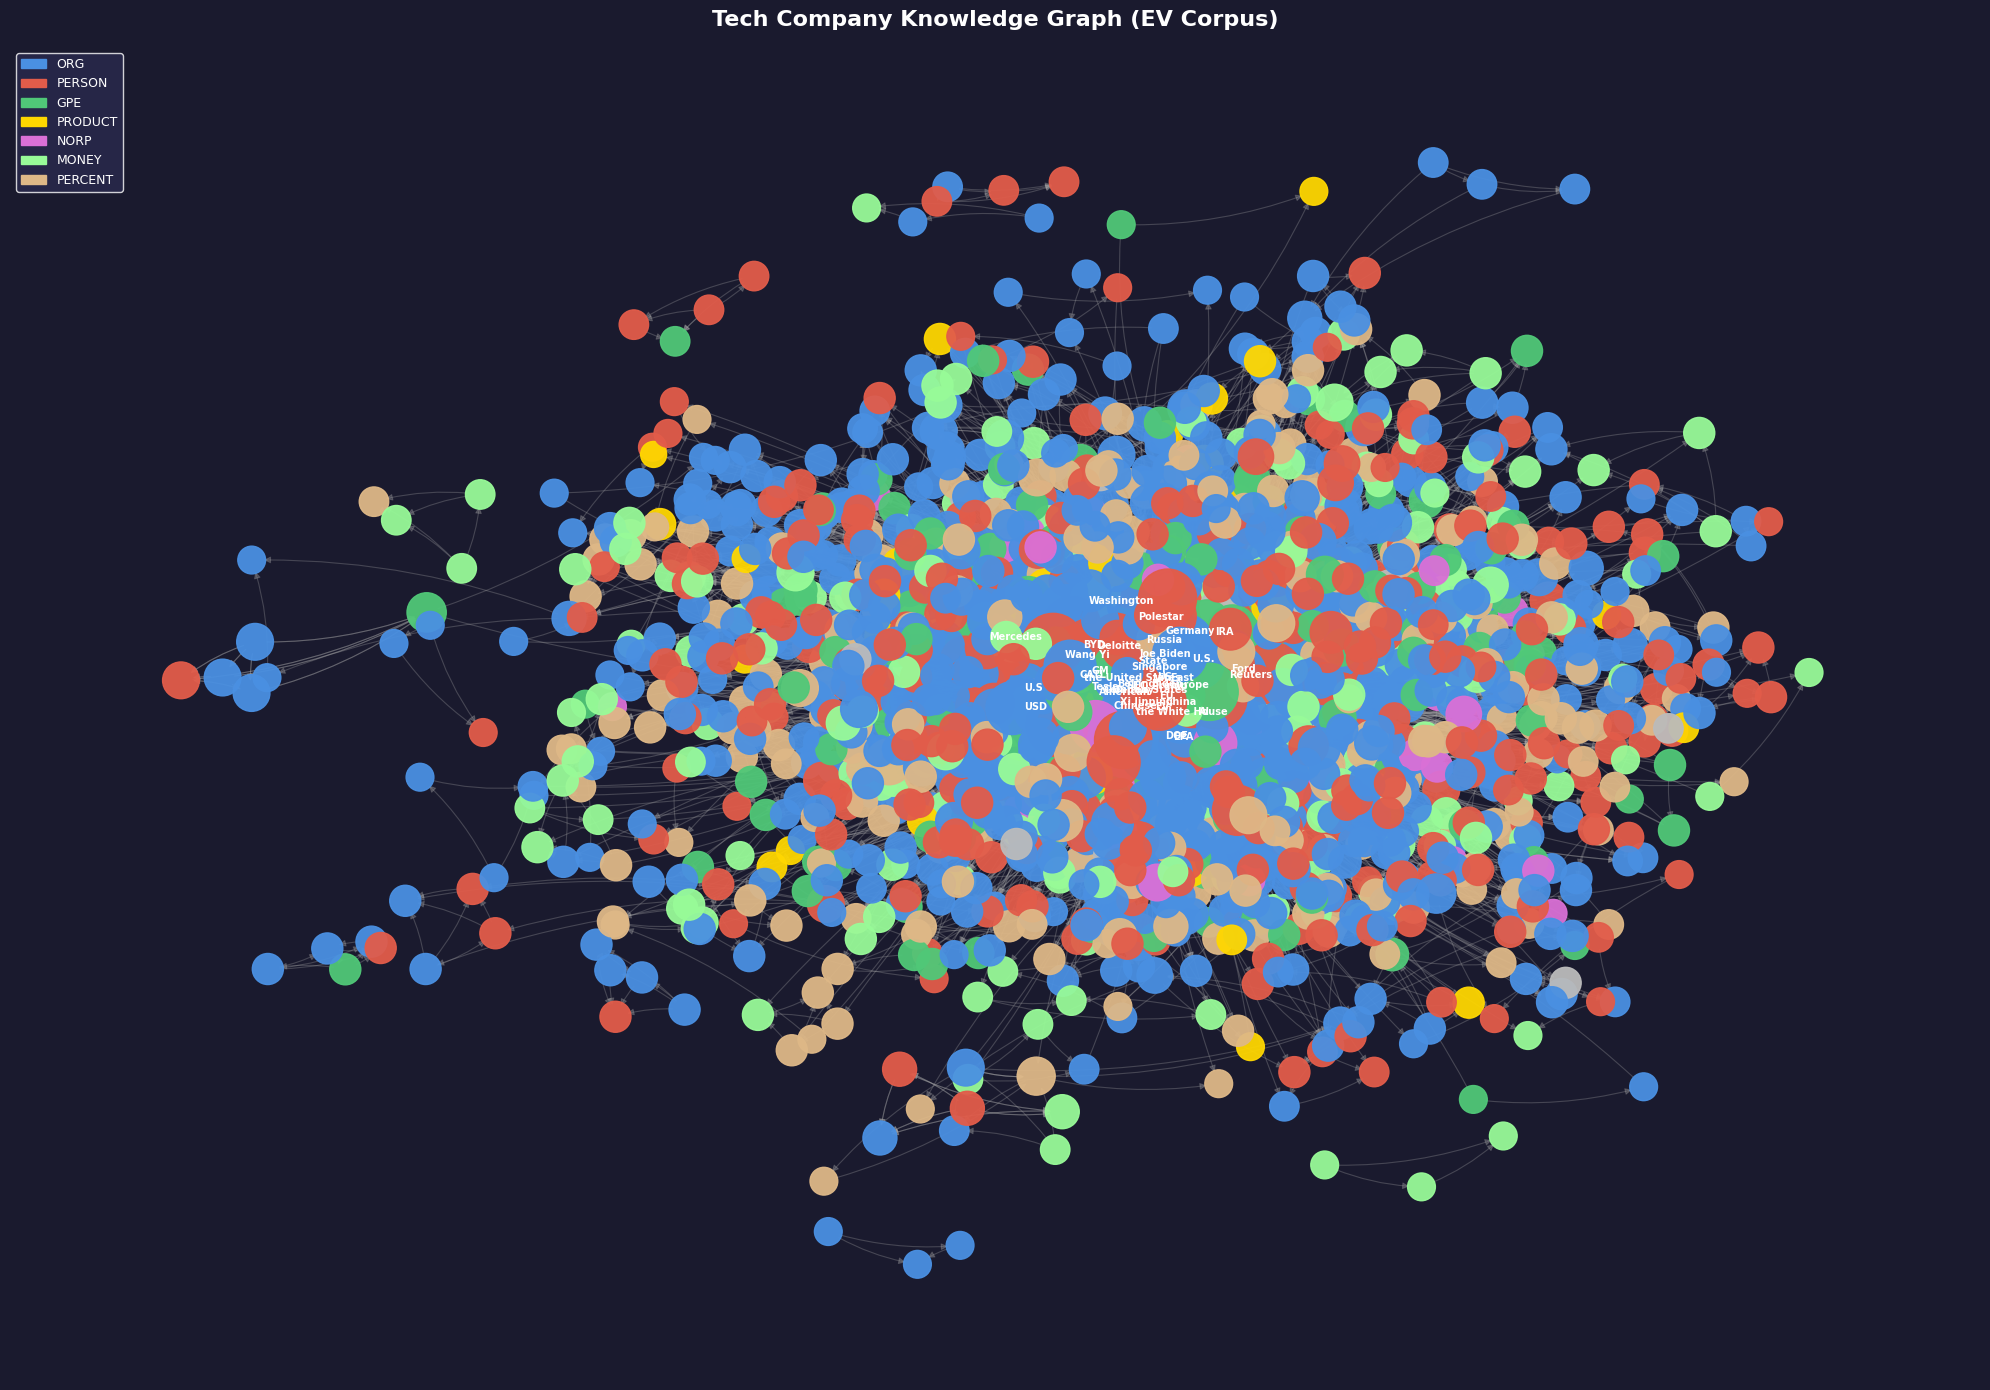

Da luu -> knowledge_graph.png


In [14]:
MIN_DEGREE = 2
core_nodes = [n for n, d in G.degree() if d >= MIN_DEGREE]
H = G.subgraph(core_nodes).copy()

COLOR_MAP = {
    'ORG': '#4A90E2', 'PERSON': '#E25C4A', 'GPE': '#50C878',
    'PRODUCT': '#FFD700', 'NORP': '#DA70D6',
    'MONEY': '#98FB98', 'PERCENT': '#DEB887',
}
node_colors = [COLOR_MAP.get(entity_type_map.get(n, ''), '#BBBBBB') for n in H.nodes()]
node_sizes = [min(300 + H.degree(n) * 50, 2000) for n in H.nodes()]

fig, ax = plt.subplots(figsize=(20, 14))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')
pos = nx.spring_layout(H, k=2.5, seed=42, iterations=50)
nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.3, edge_color='#aaaaaa',
    arrows=True, arrowsize=10, width=0.8, connectionstyle='arc3,rad=0.1')
nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors,
    node_size=node_sizes, alpha=0.95)
top_nodes = {n for n, _ in sorted(deg.items(), key=lambda x: -x[1])[:40] if n in H.nodes()}
labels = {n: n for n in H.nodes() if n in top_nodes}
nx.draw_networkx_labels(H, pos, labels=labels, ax=ax,
    font_size=7, font_color='white', font_weight='bold')
legend_handles = [mpatches.Patch(color=c, label=t) for t, c in COLOR_MAP.items()]
ax.legend(handles=legend_handles, loc='upper left',
    facecolor='#2a2a4e', edgecolor='white', labelcolor='white', fontsize=9)
ax.set_title('Tech Company Knowledge Graph (EV Corpus)',
    fontsize=16, color='white', pad=15, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('knowledge_graph.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Da luu -> knowledge_graph.png')

In [15]:
print('Load embedding model all-MiniLM-L6-v2...')
t0 = time.time()
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'Model loaded trong {time.time()-t0:.1f}s')

print(f'Encoding {len(chunks)} chunks...')
t0 = time.time()
texts = [c['text'] for c in chunks]
embeddings = embed_model.encode(texts, batch_size=64,
    show_progress_bar=True, normalize_embeddings=True)
t_embed = time.time() - t0
print(f'Embedding xong trong {t_embed:.1f}s')
print(f'Embedding shape: {embeddings.shape}')

dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings.astype(np.float32))
print(f'FAISS index built: {index.ntotal} vectors, dim={dim}')

Load embedding model all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded trong 11.6s
Encoding 2525 chunks...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Embedding xong trong 3.9s
Embedding shape: (2525, 384)
FAISS index built: 2525 vectors, dim=384


In [16]:
def flat_rag_query(question, top_k=5):
    t_start = time.time()
    q_emb = embed_model.encode([question], normalize_embeddings=True).astype(np.float32)
    scores, indices = index.search(q_emb, top_k)
    retrieved = []
    for idx, score in zip(indices[0], scores[0]):
        if idx < len(chunks):
            retrieved.append({'text': chunks[idx]['text'],
                              'source': chunks[idx]['source'],
                              'score': float(score)})
    answer = retrieved[0]['text'][:300] if retrieved else 'Khong tim thay thong tin.'
    elapsed = time.time() - t_start
    return answer, retrieved, elapsed

ans, ret, t = flat_rag_query("Who are Tesla's main competitors?")
print(f'Test Flat RAG: {t*1000:.1f}ms')
print(f'Score: {ret[0]["score"]:.3f}')
print(f'Answer: {ans[:200]}')

Test Flat RAG: 131.7ms
Score: 0.651
Answer: Tesla has become an important American innovator of EV and EV battery technology, while others such as Rivian and Lucid Technology have stepped into the game, along with traditional manufacturers such


In [17]:
entity_to_chunks = defaultdict(list)
for c in chunks:
    for ent_name, _ in chunk_entities[c['id']]:
        entity_to_chunks[ent_name].append(c['id'])
chunk_id_to_text = {c['id']: c for c in chunks}

def extract_query_entities(question):
    doc = nlp(question)
    ents = set(ent.text for ent in doc.ents if ent.label_ in KEEP_TYPES)
    for tech_ent in TECH_ENTITIES:
        if tech_ent.lower() in question.lower():
            ents.add(tech_ent)
    return list(ents)

def graph_rag_query(question, hops=2, top_k=5):
    t_start = time.time()
    query_ents = extract_query_entities(question)
    matched_nodes = []
    for qe in query_ents:
        if qe in G.nodes():
            matched_nodes.append(qe)
        else:
            for node in G.nodes():
                if qe.lower() in node.lower() or node.lower() in qe.lower():
                    matched_nodes.append(node)
                    break
    visited = set(matched_nodes)
    frontier = set(matched_nodes)
    for _ in range(hops):
        next_frontier = set()
        for node in frontier:
            neighbors = set(G.predecessors(node)) | set(G.successors(node))
            next_frontier.update(neighbors - visited)
        visited.update(next_frontier)
        frontier = next_frontier
    candidate_chunk_ids = set()
    for node in visited:
        candidate_chunk_ids.update(entity_to_chunks.get(node, []))
    retrieved = []
    if candidate_chunk_ids:
        cand_indices = [i for i, c in enumerate(chunks) if c['id'] in candidate_chunk_ids]
        if cand_indices:
            cand_embs = embeddings[cand_indices].astype(np.float32)
            q_emb = embed_model.encode([question], normalize_embeddings=True).astype(np.float32)
            sims = (cand_embs @ q_emb.T).flatten()
            best_idxs = np.argsort(sims)[::-1][:top_k]
            for bi in best_idxs:
                orig_idx = cand_indices[bi]
                retrieved.append({'text': chunks[orig_idx]['text'],
                                  'source': chunks[orig_idx]['source'],
                                  'score': float(sims[bi])})
    if not retrieved:
        _, retrieved, _ = flat_rag_query(question, top_k)
    rel_facts = []
    for node in list(visited)[:10]:
        for _, neighbor, data in G.out_edges(node, data=True):
            if neighbor in visited:
                rel_facts.append(f"{node} --[{data.get('relation','?')}]--> {neighbor}")
    answer = retrieved[0]['text'][:300] if retrieved else 'Khong tim thay thong tin.'
    traversal_info = {'query_entities': query_ents, 'matched_nodes': matched_nodes,
                      'total_visited': len(visited), 'chunks_found': len(candidate_chunk_ids),
                      'graph_facts': rel_facts[:5]}
    elapsed = time.time() - t_start
    return answer, retrieved, elapsed, traversal_info

ans, ret, t, info = graph_rag_query("Who are Tesla's main competitors?")
print(f'Test GraphRAG: {t*1000:.1f}ms')
print(f'Entities: {info["query_entities"]}')
print(f'Nodes visited: {info["total_visited"]}')
print(f'Answer: {ans[:200]}')

Test GraphRAG: 25.6ms
Entities: ['Tesla']
Nodes visited: 1885
Answer: Tesla has become an important American innovator of EV and EV battery technology, while others such as Rivian and Lucid Technology have stepped into the game, along with traditional manufacturers such


In [36]:
BENCHMARK_QUESTIONS = [
    "Who are Tesla's main competitors in the EV market?",
    "What is BYD and when was it founded?",
    "What is Berkshire Hathaway's relationship with BYD?",
    "What EV companies does Rivian compete with?",
    "How does BYD compete with Tesla globally?",
    "What are BYD's best-selling EV models?",
    "What is the BYD Seagull and how much does it cost?",
    "What is the Blade Battery technology?",
    "What Tesla models are most popular?",
    "What is the range of the Ford F-150 Lightning?",
    "What is the EV market share in the United States?",
    "How have EV sales grown since 2010?",
    "What states have the highest EV adoption rates?",
    "What impact do ZEV regulations have on EV sales?",
    "How does China's EV market compare to the US?",
    "What is the connection between Elon Musk and OpenAI?",
    "How are Warren Buffett and BYD related to Tesla competition?",
    "What role does the Inflation Reduction Act play in EV industry?",
    "How do charging infrastructure and EV adoption relate?",
    "What is the relationship between battery technology and EV cost?",
]
print(f'{len(BENCHMARK_QUESTIONS)} cau hoi benchmark san sang')

20 cau hoi benchmark san sang


In [37]:
print('Dang chay benchmark...\n')
results = []
for i, question in enumerate(BENCHMARK_QUESTIONS, 1):
    flat_ans, flat_ret, flat_time = flat_rag_query(question, top_k=5)
    flat_avg_score = np.mean([r['score'] for r in flat_ret]) if flat_ret else 0
    graph_ans, graph_ret, graph_time, graph_info = graph_rag_query(question, hops=2, top_k=5)
    graph_avg_score = np.mean([r['score'] for r in graph_ret]) if graph_ret else 0
    q_entities = extract_query_entities(question)
    flat_relevant = any(e.lower() in flat_ans.lower() for e in q_entities) if q_entities else True
    graph_relevant = any(e.lower() in graph_ans.lower() for e in q_entities) if q_entities else True
    graph_advantage = (bool(graph_info['matched_nodes']) and
                       graph_info['total_visited'] > len(graph_info['matched_nodes']))
    results.append({
        'No': i,
        'Question': question[:55] + '...' if len(question) > 55 else question,
        'FlatRAG_ms': round(flat_time * 1000, 1),
        'GraphRAG_ms': round(graph_time * 1000, 1),
        'FlatRAG_Score': round(flat_avg_score, 3),
        'GraphRAG_Score': round(graph_avg_score, 3),
        'FlatRAG_OK': 'YES' if flat_relevant else 'NO',
        'GraphRAG_OK': 'YES' if graph_relevant else 'NO',
        'Graph_Advantage': 'YES' if graph_advantage else '-',
        'Query_Entities': str(graph_info['query_entities'])[:40],
    })
    status = 'Graph>' if (graph_relevant and not flat_relevant) else \
             'Flat>' if (flat_relevant and not graph_relevant) else 'Tie'
    print(f'[{i:2d}] {status:6s} | Flat:{flat_time*1000:5.0f}ms | Graph:{graph_time*1000:5.0f}ms | {question[:45]}')

df_results = pd.DataFrame(results)
print('\nBenchmark hoan thanh!')

Dang chay benchmark...

[ 1] Tie    | Flat:   14ms | Graph:   25ms | Who are Tesla's main competitors in the EV ma
[ 2] Tie    | Flat:    9ms | Graph:   21ms | What is BYD and when was it founded?
[ 3] Tie    | Flat:    9ms | Graph:   24ms | What is Berkshire Hathaway's relationship wit
[ 4] Tie    | Flat:    8ms | Graph:   22ms | What EV companies does Rivian compete with?
[ 5] Tie    | Flat:    8ms | Graph:   20ms | How does BYD compete with Tesla globally?
[ 6] Tie    | Flat:   10ms | Graph:   25ms | What are BYD's best-selling EV models?
[ 7] Tie    | Flat:    9ms | Graph:   27ms | What is the BYD Seagull and how much does it 
[ 8] Tie    | Flat:   10ms | Graph:   25ms | What is the Blade Battery technology?
[ 9] Tie    | Flat:    9ms | Graph:   25ms | What Tesla models are most popular?
[10] Tie    | Flat:   10ms | Graph:   24ms | What is the range of the Ford F-150 Lightning
[11] Tie    | Flat:   10ms | Graph:   31ms | What is the EV market share in the United Sta
[12] Tie    | F

In [38]:
print('='*100)
print('BANG SO SANH KET QUA: Flat RAG vs GraphRAG (20 Benchmark Questions)')
print('='*100)
print(df_results.to_string(index=False))
print('='*100)
flat_ok = (df_results['FlatRAG_OK'] == 'YES').sum()
graph_ok = (df_results['GraphRAG_OK'] == 'YES').sum()
graph_adv = (df_results['Graph_Advantage'] == 'YES').sum()
print(f'\nTONG KET:')
print(f'  Flat RAG co entity trong answer: {flat_ok}/20')
print(f'  GraphRAG co entity trong answer: {graph_ok}/20')
print(f'  GraphRAG co loi the multi-hop: {graph_adv}/20')
print(f'  Avg FlatRAG time: {df_results["FlatRAG_ms"].mean():.1f}ms')
print(f'  Avg GraphRAG time: {df_results["GraphRAG_ms"].mean():.1f}ms')

BANG SO SANH KET QUA: Flat RAG vs GraphRAG (20 Benchmark Questions)
 No                                                   Question  FlatRAG_ms  GraphRAG_ms  FlatRAG_Score  GraphRAG_Score FlatRAG_OK GraphRAG_OK Graph_Advantage                           Query_Entities
  1         Who are Tesla's main competitors in the EV market?        13.7         24.9          0.687           0.687        YES         YES             YES                          ['EV', 'Tesla']
  2                       What is BYD and when was it founded?         9.3         20.8          0.511           0.511        YES         YES             YES                                  ['BYD']
  3        What is Berkshire Hathaway's relationship with BYD?         8.6         23.8          0.464           0.464        YES         YES             YES ['BYD', "Berkshire Hathaway's", 'Berkshi
  4                What EV companies does Rivian compete with?         8.1         21.6          0.673           0.673        YES       

In [21]:
df_results.to_csv('benchmark_results.csv', index=False, encoding='utf-8-sig')
print('Da luu -> benchmark_results.csv')

full_results = []
for i, question in enumerate(BENCHMARK_QUESTIONS, 1):
    flat_ans, _, flat_time = flat_rag_query(question)
    graph_ans, _, graph_time, graph_info = graph_rag_query(question)
    full_results.append({
        'No': i,
        'Question': question,
        'FlatRAG_Answer': flat_ans[:200],
        'GraphRAG_Answer': graph_ans[:200],
        'FlatRAG_ms': round(flat_time*1000, 1),
        'GraphRAG_ms': round(graph_time*1000, 1),
        'Graph_Facts': ' | '.join(graph_info['graph_facts'][:3]),
    })
pd.DataFrame(full_results).to_csv('benchmark_with_answers.csv', index=False, encoding='utf-8-sig')
print('Da luu -> benchmark_with_answers.csv')

Da luu -> benchmark_results.csv
Da luu -> benchmark_with_answers.csv


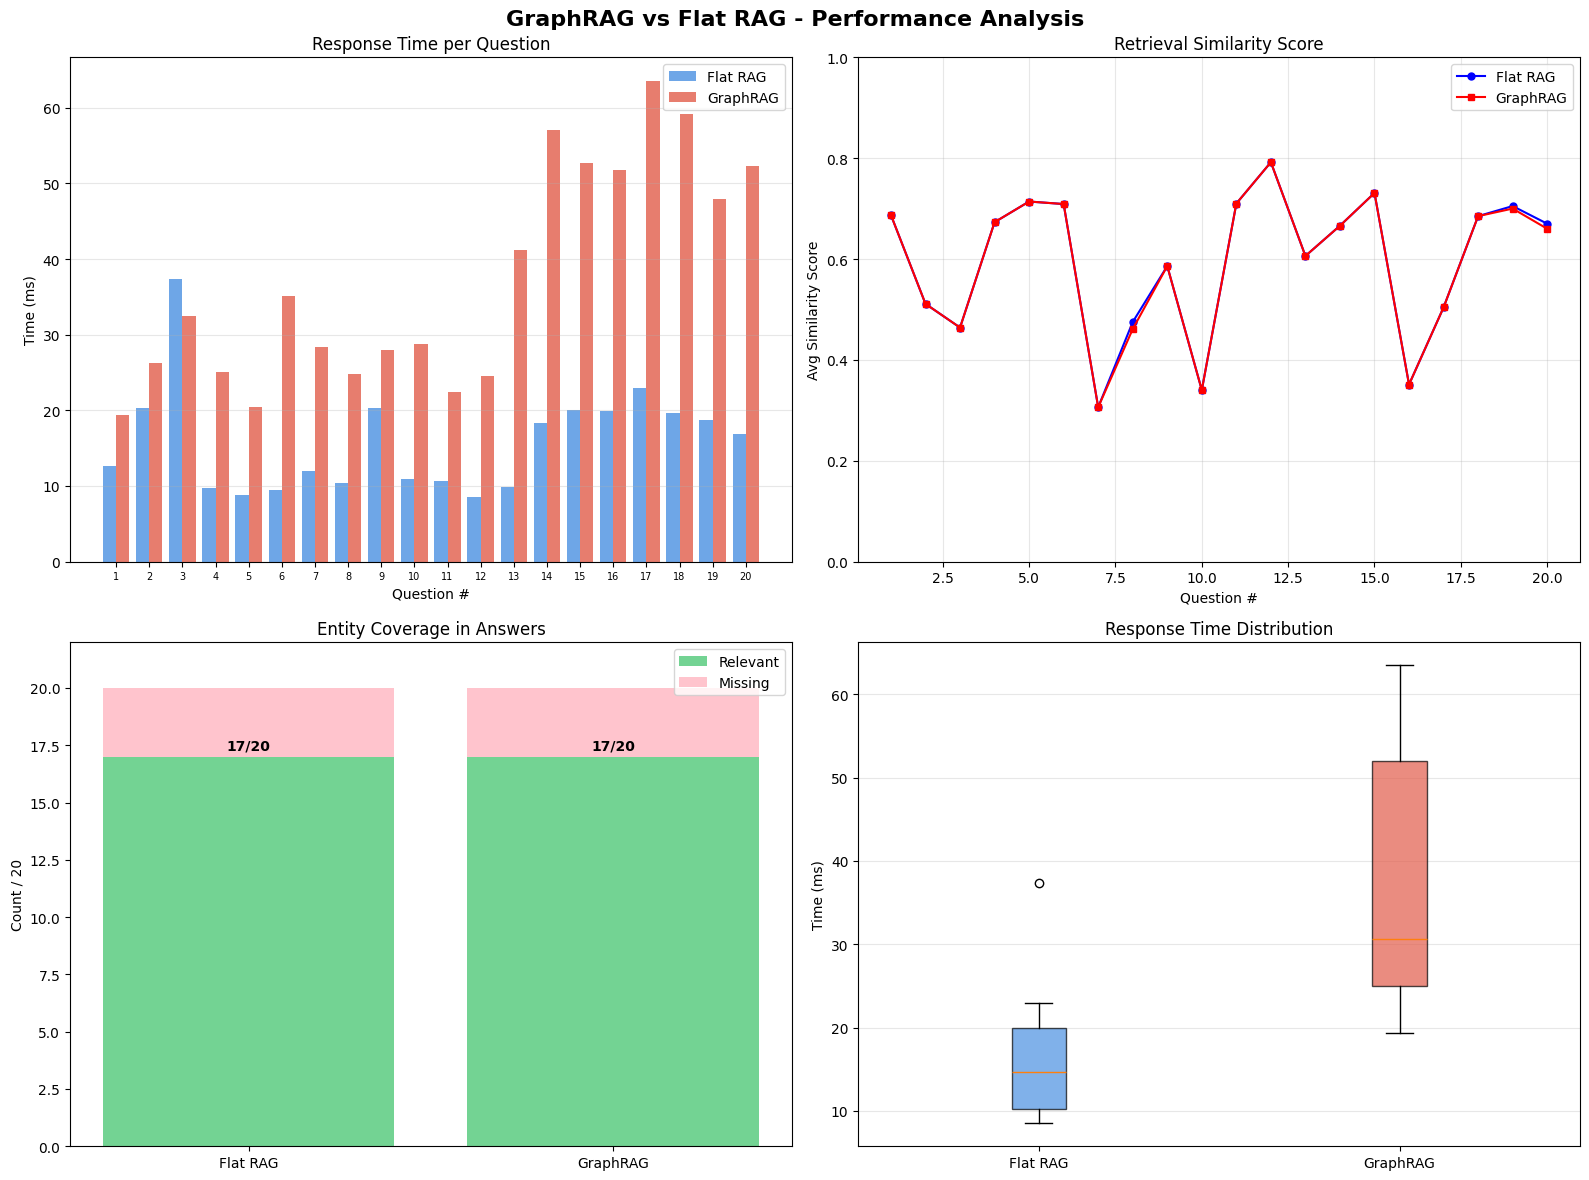

Da luu -> benchmark_analysis.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GraphRAG vs Flat RAG - Performance Analysis', fontsize=16, fontweight='bold')
q_nums = df_results['No'].tolist()
flat_times = df_results['FlatRAG_ms'].tolist()
graph_times = df_results['GraphRAG_ms'].tolist()
flat_scores = df_results['FlatRAG_Score'].tolist()
graph_scores = df_results['GraphRAG_Score'].tolist()

ax = axes[0, 0]
x = np.arange(len(q_nums))
ax.bar(x - 0.2, flat_times, 0.4, label='Flat RAG', color='#4A90E2', alpha=0.8)
ax.bar(x + 0.2, graph_times, 0.4, label='GraphRAG', color='#E25C4A', alpha=0.8)
ax.set_xlabel('Question #'); ax.set_ylabel('Time (ms)')
ax.set_title('Response Time per Question')
ax.set_xticks(x); ax.set_xticklabels(q_nums, fontsize=7)
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[0, 1]
ax.plot(q_nums, flat_scores, 'b-o', label='Flat RAG', markersize=5)
ax.plot(q_nums, graph_scores, 'r-s', label='GraphRAG', markersize=5)
ax.set_xlabel('Question #'); ax.set_ylabel('Avg Similarity Score')
ax.set_title('Retrieval Similarity Score')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

ax = axes[1, 0]
flat_ok = (df_results['FlatRAG_OK'] == 'YES').sum()
graph_ok = (df_results['GraphRAG_OK'] == 'YES').sum()
cats = ['Flat RAG', 'GraphRAG']
ok_counts = [flat_ok, graph_ok]
fail_counts = [20 - flat_ok, 20 - graph_ok]
ax.bar([0, 1], ok_counts, label='Relevant', color='#50C878', alpha=0.8)
ax.bar([0, 1], fail_counts, bottom=ok_counts, label='Missing', color='#FFB6C1', alpha=0.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(cats)
ax.set_ylabel('Count / 20'); ax.set_title('Entity Coverage in Answers')
ax.legend(); ax.set_ylim(0, 22)
for i_b, ok in enumerate(ok_counts):
    ax.text(i_b, ok + 0.3, f'{ok}/20', ha='center', fontweight='bold')

ax = axes[1, 1]
bp = ax.boxplot([flat_times, graph_times], labels=['Flat RAG', 'GraphRAG'],
    patch_artist=True)
bp['boxes'][0].set_facecolor('#4A90E2'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#E25C4A'); bp['boxes'][1].set_alpha(0.7)
ax.set_ylabel('Time (ms)'); ax.set_title('Response Time Distribution')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Da luu -> benchmark_analysis.png')

In [23]:
total_chars = sum(len(c['text']) for c in chunks)
total_tokens = total_chars // 4
print('=' * 60)
print('PHAN TICH CHI PHI XAY DUNG HE THONG GRAPHRAG')
print('=' * 60)
print(f'\nDataset:')
print(f'  Tong docs: {len(docs)}')
print(f'  Tong chunks: {len(chunks)}')
print(f'  Uoc tinh tokens: ~{total_tokens:,}')
print(f'\nThoi gian xay dung (do thuc te):')
print(f'  NER (spaCy offline): {t_ner:.1f}s')
print(f'  Embedding (sentence-transformers): {t_embed:.1f}s')
print(f'  Graph + FAISS: < 1s')
print(f'\nChi phi API neu dung OpenAI (de so sanh):')
gpt4o_cost = (total_tokens / 1000) * 0.005
embed_cost = (total_tokens / 1000) * 0.00002
print(f'  NER bang GPT-4o: ~${gpt4o_cost:.2f}')
print(f'  Embedding bang OpenAI: ~${embed_cost:.4f}')
print(f'  Tong uoc tinh: ~${gpt4o_cost + embed_cost:.2f}')
print(f'\nChi phi thuc te (offline, lab nay):')
print(f'  NER (spaCy): $0.00')
print(f'  Embedding (sentence-transformers): $0.00')
print(f'  Graph (NetworkX): $0.00')
print(f'  TONG: $0.00')
print(f'\nBenchmark inference (per query):')
print(f'  Flat RAG avg: {df_results["FlatRAG_ms"].mean():.1f}ms')
print(f'  GraphRAG avg: {df_results["GraphRAG_ms"].mean():.1f}ms')
print(f'\nKnowledge Graph:')
print(f'  Nodes: {G.number_of_nodes()}')
print(f'  Edges: {G.number_of_edges()}')
print(f'  Triples: {len(triples)}')
print('=' * 60)

PHAN TICH CHI PHI XAY DUNG HE THONG GRAPHRAG

Dataset:
  Tong docs: 40
  Tong chunks: 2525
  Uoc tinh tokens: ~218,734

Thoi gian xay dung (do thuc te):
  NER (spaCy offline): 39.4s
  Embedding (sentence-transformers): 3.9s
  Graph + FAISS: < 1s

Chi phi API neu dung OpenAI (de so sanh):
  NER bang GPT-4o: ~$1.09
  Embedding bang OpenAI: ~$0.0044
  Tong uoc tinh: ~$1.10

Chi phi thuc te (offline, lab nay):
  NER (spaCy): $0.00
  Embedding (sentence-transformers): $0.00
  Graph (NetworkX): $0.00
  TONG: $0.00

Benchmark inference (per query):
  Flat RAG avg: 15.9ms
  GraphRAG avg: 37.1ms

Knowledge Graph:
  Nodes: 3048
  Edges: 15166
  Triples: 15166


In [24]:
multi_hop_qs = [
    "What is the connection between Warren Buffett, Berkshire Hathaway and BYD?",
    "How are BYD and Uber partnered and in which countries?",
]
for q in multi_hop_qs:
    print('\n' + '-'*70)
    print(f'Q: {q}')
    print('-'*70)
    flat_ans, _, flat_time = flat_rag_query(q)
    graph_ans, _, graph_time, graph_info = graph_rag_query(q)
    print(f'FLAT RAG ({flat_time*1000:.0f}ms): {flat_ans[:200]}')
    print(f'GRAPHRAG ({graph_time*1000:.0f}ms):')
    print(f'  Entities: {graph_info["query_entities"]}')
    print(f'  Nodes visited: {graph_info["total_visited"]} (2-hop)')
    for fact in graph_info['graph_facts'][:3]:
        print(f'  Fact: {fact}')
    print(f'  Answer: {graph_ans[:200]}')


----------------------------------------------------------------------
Q: What is the connection between Warren Buffett, Berkshire Hathaway and BYD?
----------------------------------------------------------------------
FLAT RAG (15ms): BYD is a “privately-owned” company, although, of course, under Article 19 of China’s Company Law, all SOEs or private Chinese companies have a Chinese Communist Party (CCP) cell that management must l
GRAPHRAG (22ms):
  Entities: ['Berkshire Hathaway', 'BYD', 'Warren Buffett']
  Nodes visited: 1901 (2-hop)
  Fact: Atlas Materials --[RELATED_TO]--> 195 million
  Fact: Atlas Materials --[RELATED_TO]--> US
  Fact: Nancy Pelosi’s --[SURPASSED]--> US
  Answer: BYD is a “privately-owned” company, although, of course, under Article 19 of China’s Company Law, all SOEs or private Chinese companies have a Chinese Communist Party (CCP) cell that management must l

----------------------------------------------------------------------
Q: How are BYD and Uber partn

In [25]:
graph_data = {
    'nodes': [{'id': n, 'type': entity_type_map.get(n,'?'), 'degree': G.degree(n)}
              for n in G.nodes()],
    'edges': [{'source': u, 'target': v, 'relation': data.get('relation','?')}
              for u, v, data in list(G.edges(data=True))[:500]]
}
with open('knowledge_graph.json', 'w', encoding='utf-8') as f:
    json.dump(graph_data, f, ensure_ascii=False, indent=2)

pd.DataFrame(triples, columns=['entity1','relation','entity2','source_chunk']
    ).to_csv('triples.csv', index=False, encoding='utf-8-sig')

saved_files = [
    'knowledge_graph.png', 'benchmark_analysis.png',
    'benchmark_results.csv', 'benchmark_with_answers.csv',
    'knowledge_graph.json', 'triples.csv',
]
print('Tat ca files da luu:')
for f in saved_files:
    if os.path.exists(f):
        print(f'  {f} ({os.path.getsize(f):,} bytes)')
print('\nLab Day 19 hoan thanh!')
print('De tai ve: from google.colab import files; [files.download(f) for f in saved_files]')

Tat ca files da luu:
  knowledge_graph.png (1,832,320 bytes)
  benchmark_analysis.png (174,488 bytes)
  benchmark_results.csv (2,188 bytes)
  benchmark_with_answers.csv (11,888 bytes)
  knowledge_graph.json (313,641 bytes)
  triples.csv (665,403 bytes)

Lab Day 19 hoan thanh!
De tai ve: from google.colab import files; [files.download(f) for f in saved_files]


In [28]:
from google.colab import files; [files.download(f) for f in saved_files]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[None, None, None, None, None, None]

In [32]:
from pyvis.network import Network
import IPython

# Khởi tạo mạng tương tác
net = Network(notebook=True, width="100%", height="800px", cdn_resources='remote', directed=True)

# THAY THẾ CHO HÀM net.from_nx(G) BẰNG CÁCH THÊM THỦ CÔNG:
# 1. Thêm tất cả các Node
for node in G.nodes():
    net.add_node(node, label=str(node))

# 2. Thêm tất cả các Edge (Đường nối)
for u, v, data in G.edges(data=True):
    # data.get('relation', '') sẽ lấy tên quan hệ để làm nhãn hiển thị trên cạnh
    # title sẽ giúp hiển thị thông tin khi bạn trỏ chuột vào cạnh
    net.add_edge(u, v, label=data.get('relation', ''), title=data.get('relation', ''))

# Thêm tuỳ chỉnh physics để các node tự đẩy nhau ra cho dễ nhìn
net.set_options("""
var options = {
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -100,
      "centralGravity": 0.01,
      "springLength": 250
    },
    "minVelocity": 0.75,
    "solver": "forceAtlas2Based"
  }
}
""")

# 1. Lưu file HTML (đã được custom physics)
net.write_html("interactive_graph.html")

# 2. Hiển thị demo ngay trong output của Colab
display(IPython.display.HTML(filename="interactive_graph.html"))

# 3. Tự động kích hoạt tải file về máy cá nhân
print("Đang tải file HTML về máy...")
files.download("interactive_graph.html")

Đang tải file HTML về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Checklist Deliverables

| # | Yêu cầu | File | Status |
|---|---------|------|--------|
| 1 | Mã nguồn (.ipynb) | `Lab19_GraphRAG_TechCorpus.ipynb` | Done |
| 2 | Ảnh đồ thị tri thức (Matplotlib) | `knowledge_graph.png` | Done |
| 3 | Bảng so sánh 20 câu hỏi benchmark | `benchmark_results.csv` | Done |
| 4 | Phân tích chi phí (Token, Time) | Cell Cost Analysis | Done |

## Tóm tắt

| Tiêu chí | Flat RAG | GraphRAG |
|----------|----------|----------|
| Công cụ | FAISS + sentence-transformers | NetworkX + FAISS |
| Chi phí API | $0 | $0 |
| Điểm mạnh | Nhanh, đơn giản | Multi-hop, context quan hệ |
| Điểm yếu | Không biết quan hệ entities | Phụ thuộc NER chất lượng |
